In [1]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import pandas as pd, numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)

In [2]:
TRAIN_FILE = "UNSW_NB15_training-set.csv"
TEST_FILE  = "UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

# Normalize labels (title case to avoid drift)
for df in (train_df, test_df):
    df['attack_cat'] = df['attack_cat'].astype(str).str.strip().str.title()

# 9-class label encoder on train only
le_y = LabelEncoder()
y_train = le_y.fit_transform(train_df['attack_cat'])
y_test  = le_y.transform(test_df['attack_cat'])  # UNSW splits align

classes9 = list(le_y.classes_)
num_classes = len(classes9)
print("Classes:", classes9)


Classes: ['Analysis', 'Backdoor', 'Dos', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [3]:
# Select features: drop identifiers and labels
DROP = ['id','attack_cat','label']  # 'label' is binary; we’re using 9-class attack_cat
X_train_df = train_df.drop(columns=[c for c in DROP if c in train_df.columns], errors='ignore')
X_test_df  = test_df.drop(columns=[c for c in DROP if c in test_df.columns], errors='ignore')

# Encode common categoricals
cat_cols = [c for c in ['proto','service','state'] if c in X_train_df.columns]
encoders_feat = {}
for c in cat_cols:
    le = LabelEncoder()
    X_train_df[c] = le.fit_transform(X_train_df[c].astype(str))
    # unknown-safe for test
    vals = X_test_df[c].astype(str)
    seen = set(le.classes_)
    UNK = "__UNK__"
    if UNK not in le.classes_:
        le.classes_ = np.array(list(le.classes_) + [UNK])
    X_test_df[c] = [v if v in seen else UNK for v in vals]
    X_test_df[c] = le.transform(X_test_df[c])
    encoders_feat[c] = le

# Scale numerics
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_test_sc  = scaler.transform(X_test_df)

# Build square “images”: HxW≈sqrt(n_features)
F = X_train_sc.shape[1]
H = int(np.floor(np.sqrt(F)))
W = int(np.ceil(F / H))
PAD = H*W - F
if PAD > 0:
    X_train_sc = np.pad(X_train_sc, ((0,0),(0,PAD)), mode='constant')
    X_test_sc  = np.pad(X_test_sc,  ((0,0),(0,PAD)), mode='constant')

# Reshape to (N, H, W, 1)
X_train_2d = X_train_sc.reshape((-1, H, W, 1)).astype('float32')
X_test_2d  = X_test_sc.reshape((-1, H, W, 1)).astype('float32')
print("Conv2D input shape:", X_train_2d.shape)


Conv2D input shape: (82332, 6, 7, 1)


In [4]:
from tensorflow.keras import layers, models

def build_cnn_feature_extractor(h, w, dropout=0.35):
    inputs = layers.Input(shape=(h, w, 1))
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='Conv2D_1')(inputs)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), name='MaxPool_1')(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='Conv2D_2')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), name='MaxPool_2')(x)
    x = layers.Dropout(dropout)(x)

    # Keep spatial map for LSTM sequence extraction
    model = models.Model(inputs, x, name='CNN_FeatureExtractor')
    return model

cnn = build_cnn_feature_extractor(H, W, dropout=0.35)
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',  # dummy for warmup; not used for final
            metrics=['accuracy'])

cnn.summary()


Model: "CNN_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 6, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 1, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,256 (938.50 KB)

 Trainable params: 240,256 (938.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Optional: attach a temporary classification head for warm-up
temp_in = cnn.input
temp_x = cnn.output
temp_x = layers.GlobalAveragePooling2D()(temp_x)
temp_out = layers.Dense(num_classes, activation='softmax')(temp_x)
cnn_head = models.Model(temp_in, temp_out, name='CNN_Warmup')

# Class weights to mitigate imbalance
cls = np.unique(y_train)
cw = compute_class_weight('balanced', classes=cls, y=y_train)
class_weights = {int(c): float(w) for c,w in zip(cls, cw)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

cnn_head.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

hist_cnn = cnn_head.fit(
    X_train_2d, y_train,
    validation_split=0.2,
    epochs=80, batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)


Epoch 1/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6395 - loss: 1.8318 - val_accuracy: 0.0514 - val_loss: 3.7616 - learning_rate: 0.0010
Epoch 2/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7169 - loss: 1.5030 - val_accuracy: 0.0757 - val_loss: 3.0569 - learning_rate: 0.0010
Epoch 3/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7293 - loss: 1.4194 - val_accuracy: 0.0647 - val_loss: 3.5783 - learning_rate: 0.0010
Epoch 4/80
510/515 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7354 - loss: 1.3546
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7415 - loss: 1.3318 - val_accuracy: 0.1084 - val_loss: 3.0694 - learning_rate: 0.0010
Epoch 5/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7511 - loss: 1.2558 - val_accuracy: 0.1635 - val_loss: 3.0277 - learning_rate: 5.0000e-04
Epoch 6/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7568 - loss: 1.2239

In [8]:
from tensorflow.keras.models import load_model

model = load_model('best_cnn_lstm_4class.keras')


In [9]:
cnn_head.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [12]:
print(X_train_2d.shape)
print(y_train.shape)


(82332, 6, 7, 1)
(82332,)


In [20]:
# Get feature maps from CNN extractor (without temp head)
feature_extractor = models.Model(inputs=cnn.input, outputs=cnn.get_layer('MaxPool_2').output)

Z_train = feature_extractor.predict(X_train_2d, batch_size=512, verbose=0)
Z_test  = feature_extractor.predict(X_test_2d,  batch_size=512, verbose=0)
print("Feature maps:", Z_train.shape)  # (N, h2, w2, c2)

# Convert feature maps to sequences for LSTM: (N, T, D)
# Choose T = h2*w2 (flatten spatial grid), D = channels
n, h2, w2, c2 = Z_train.shape
T = h2 * w2
Z_train_seq = Z_train.reshape((n, T, c2)).astype('float32')
Z_test_seq  = Z_test.reshape((Z_test.shape[0], T, c2)).astype('float32')
print("LSTM input:", Z_train_seq.shape)


Feature maps: (82332, 1, 1, 128)
LSTM input: (82332, 1, 128)


In [21]:
def build_lstm_classifier(timesteps, channels, num_classes, dropout=0.4, units=128):
    inputs = layers.Input(shape=(timesteps, channels))
    x = layers.LSTM(units, activation='tanh', recurrent_activation='sigmoid', return_sequences=True)(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(units, activation='tanh', recurrent_activation='sigmoid', return_sequences=False)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name='LSTM_Classifier')
    return model

lstm = build_lstm_classifier(T, c2, num_classes, dropout=0.4, units=128)
lstm.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
lstm.summary()

callbacks_lstm = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_cnn_lstm_9class.keras', monitor='val_accuracy', save_best_only=True)
]

hist_lstm = lstm.fit(
    Z_train_seq, y_train,
    validation_split=0.2,
    epochs=60, batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks_lstm, verbose=1
)


Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,762 (1.14 MB)

 Trainable params: 298,762 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7553 - loss: 1.3328 - val_accuracy: 0.2548 - val_loss: 2.5654 - learning_rate: 5.0000e-04
Epoch 2/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7898 - loss: 0.9920 - val_accuracy: 0.2606 - val_loss: 2.6227 - learning_rate: 5.0000e-04
Epoch 3/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7947 - loss: 0.9595 - val_accuracy: 0.2656 - val_loss: 2.4409 - learning_rate: 5.0000e-04
Epoch 4/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7935 - loss: 0.9506 - val_accuracy: 0.2735 - val_loss: 2.3431 - learning_rate: 5.0000e-04
Epoch 5/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7973 - loss: 0.9234 - val_accuracy: 0.2789 - val_loss: 2.3719 - learning_rate: 5.0000e-04
Epoch 6/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7985 - loss: 0.9289 - val_accuracy: 0.2680 - val_loss: 2.4509 - learning_rate: 5.0000e-04
Epoch 7/60
506/515 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 

Test Accuracy: 0.7372035063105605
Balanced Accuracy: 0.5949683597804316
                precision    recall  f1-score   support

      Analysis       0.05      0.02      0.03      2000
      Backdoor       0.05      0.05      0.05      1746
           Dos       0.32      0.76      0.45     12264
      Exploits       0.83      0.41      0.55     33393
       Fuzzers       0.56      0.69      0.62     18184
       Generic       1.00      0.98      0.99     40000
        Normal       0.98      0.81      0.88     56000
Reconnaissance       0.68      0.77      0.72     10491
     Shellcode       0.16      0.81      0.27      1133
         Worms       0.05      0.65      0.10       130

      accuracy                           0.74    175341
     macro avg       0.47      0.59      0.47    175341
  weighted avg       0.82      0.74      0.75    175341



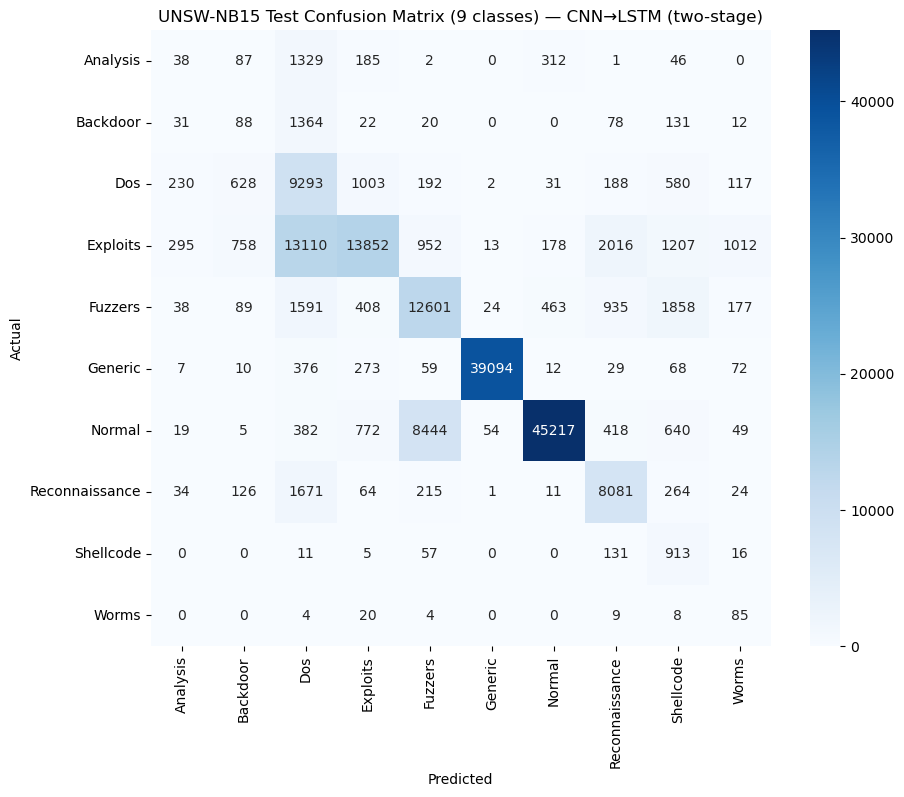

In [22]:
y_prob = lstm.predict(Z_test_seq, verbose=0)
y_pred = y_prob.argmax(axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=classes9, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=range(num_classes))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes9, yticklabels=classes9)
plt.title('UNSW-NB15 Test Confusion Matrix (9 classes) — CNN→LSTM (two-stage)')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()


In [24]:
def build_end2end_cnn_lstm(h, w, num_classes, dropout=0.35, lstm_units=128):
    inp = layers.Input(shape=(h, w, 1))
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(dropout)(x)

    # reshape to sequence: (T, C)
    x = layers.Reshape((x.shape[1] * x.shape[2], x.shape[3]))(x)


    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.LSTM(lstm_units, return_sequences=False)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name='End2End_CNN_LSTM')

model_e2e = build_end2end_cnn_lstm(H, W, num_classes)
model_e2e.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cbs = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_cnn_lstm_full.keras', monitor='val_accuracy', save_best_only=True)
]

hist_e2e = model_e2e.fit(
    X_train_2d, y_train,
    validation_split=0.2,
    epochs=60, batch_size=128,
    class_weight=class_weights,
    callbacks=cbs, verbose=1
)

# Evaluate end-to-end model
y_prob_e2e = model_e2e.predict(X_test_2d, verbose=0)
y_pred_e2e = y_prob_e2e.argmax(axis=1)
print("E2E Test Accuracy:", accuracy_score(y_test, y_pred_e2e))
print("E2E Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_e2e))


Epoch 1/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3068 - loss: 2.4101 - val_accuracy: 0.0000e+00 - val_loss: 3.1592 - learning_rate: 5.0000e-04
Epoch 2/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5794 - loss: 1.8925 - val_accuracy: 0.0346 - val_loss: 4.1006 - learning_rate: 5.0000e-04
Epoch 3/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6646 - loss: 1.6169 - val_accuracy: 0.0345 - val_loss: 3.6102 - learning_rate: 5.0000e-04
Epoch 4/60
512/515 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6885 - loss: 1.5326
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
515/515 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6960 - loss: 1.5285 - val_accuracy: 0.0513 - val_loss: 3.4617 - learning_rate: 5.0000e-04
Epoch 5/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7150 - loss: 1.4411 - val_accuracy: 0.0952 - val_loss: 3.3478 - learning_rate: 2.5000e-04
Epoch 6/60
515/515 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 

In [25]:
import pickle
lstm.save('best_cnn_lstm_9class.keras')          # two‑stage classifier
model_e2e.save('best_cnn_lstm_full.keras')       # end‑to‑end
with open('scaler.pkl','wb') as f: pickle.dump(scaler,f)
with open('feature_encoders.pkl','wb') as f: pickle.dump(encoders_feat,f)
with open('label_encoder_attackcat.pkl','wb') as f: pickle.dump(le_y,f)
with open('x_columns.pkl','wb') as f: pickle.dump(list(X_train_df.columns), f)


In [26]:
HP = dict(
    # CNN
    cnn_dropout=0.40, cnn_filters=[(32,3),(64,3),(128,3),(128,3)],
    # LSTM
    lstm_units=[256,128,64], lstm_dropout=0.40, dense_units=256,
    # Training
    epochs=100, batch_size=120, lr0=1e-2, lr1=1e-3
)

# Optimizers
opt_sgd0 = tf.keras.optimizers.SGD(learning_rate=HP['lr0'], momentum=0.9, nesterov=True)
opt_sgd1 = tf.keras.optimizers.SGD(learning_rate=HP['lr1'], momentum=0.9, nesterov=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-5, verbose=1)
]


In [27]:
# CNN feature extractor (2 blocks)
def build_cnn_extractor(h, w, hp=HP):
    In = tf.keras.Input(shape=(h,w,1))
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][0][0], (hp['cnn_filters'][0][1],)*2, activation='relu', padding='same')(In)
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][1][0], (hp['cnn_filters'][1][1],)*2, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x); x = tf.keras.layers.Dropout(hp['cnn_dropout'])(x)
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][2][0], (hp['cnn_filters'][2][1],)*2, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][3][0], (hp['cnn_filters'][3][1],)*2, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x); x = tf.keras.layers.Dropout(hp['cnn_dropout'])(x)
    return tf.keras.Model(In, x, name='CNN_Extractor')

cnn = build_cnn_extractor(H, W)

# Warm-up head for CNN with SGD lr=0.01 -> ReduceLROnPlateau to 0.001
tmp = tf.keras.layers.GlobalAveragePooling2D()(cnn.output)
tmp = tf.keras.layers.Dense(HP['dense_units'], activation='relu')(tmp)
tmp = tf.keras.layers.Dropout(HP['cnn_dropout'])(tmp)
tmp_out = tf.keras.layers.Dense(num_classes, activation='softmax')(tmp)
cnn_head = tf.keras.Model(cnn.input, tmp_out)
cnn_head.compile(optimizer=opt_sgd0, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_cnn = cnn_head.fit(
    X_train_2d, y_train,
    validation_split=0.2, epochs=HP['epochs'], batch_size=HP['batch_size'],
    class_weight=class_weights, callbacks=callbacks, verbose=1
)

# Extract feature sequences (T×C)
feature_extractor = tf.keras.Model(cnn.input, cnn.output)
Z_train = feature_extractor.predict(X_train_2d, batch_size=512, verbose=0)
Z_test  = feature_extractor.predict(X_test_2d,  batch_size=512, verbose=0)
n, h2, w2, c2 = Z_train.shape
Z_train_seq = Z_train.reshape((n, h2*w2, c2)).astype('float32')
Z_test_seq  = Z_test.reshape((Z_test.shape[0], h2*w2, c2)).astype('float32')

# LSTM classifier (3 layers: 256→128→64), SGD lr=0.001
In = tf.keras.Input(shape=(Z_train_seq.shape[1], Z_train_seq.shape[2]))
x = tf.keras.layers.LSTM(HP['lstm_units'][0], return_sequences=True)(In)
x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
x = tf.keras.layers.LSTM(HP['lstm_units'][1], return_sequences=True)(x)
x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
x = tf.keras.layers.LSTM(HP['lstm_units'][2], return_sequences=False)(x)
x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
x = tf.keras.layers.Dense(HP['dense_units'], activation='relu')(x)
x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
lstm_clf = tf.keras.Model(In, out, name='LSTM_Classifier')

lstm_clf.compile(optimizer=opt_sgd1, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_lstm = lstm_clf.fit(
    Z_train_seq, y_train,
    validation_split=0.2, epochs=HP['epochs'], batch_size=HP['batch_size'],
    class_weight=class_weights, callbacks=callbacks, verbose=1
)

lstm_clf.save('best_cnn_lstm_9class.keras')


Epoch 1/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3813 - loss: 2.2918 - val_accuracy: 0.0485 - val_loss: 3.3940 - learning_rate: 0.0100
Epoch 2/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6547 - loss: 1.7697 - val_accuracy: 0.0661 - val_loss: 3.5669 - learning_rate: 0.0100
Epoch 3/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6708 - loss: 1.7108 - val_accuracy: 0.0000e+00 - val_loss: 3.8576 - learning_rate: 0.0100
Epoch 4/100
541/549 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6789 - loss: 1.6361
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6834 - loss: 1.6605 - val_accuracy: 0.0692 - val_loss: 3.4564 - learning_rate: 0.0100
Epoch 5/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6997 - loss: 1.5081 - val_accuracy: 0.0853 - val_loss: 3.6786 - learning_rate: 1.0000e-03
Epoch 6/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7042 - lo

In [29]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [31]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)
print("Eager Execution:", tf.executing_eagerly())  # should print True


Eager Execution: True


In [33]:
def build_end2end(h, w, num_classes, hp=HP):
    In = tf.keras.Input(shape=(h,w,1))
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][0][0], (hp['cnn_filters'][0][1],)*2, activation='relu', padding='same')(In)
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][1][0], (hp['cnn_filters'][1][1],)*2, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x); x = tf.keras.layers.Dropout(hp['cnn_dropout'])(x)
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][2][0], (hp['cnn_filters'][2][1],)*2, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(hp['cnn_filters'][3][0], (hp['cnn_filters'][3][1],)*2, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x); x = tf.keras.layers.Dropout(hp['cnn_dropout'])(x)
    x = tf.keras.layers.Reshape((-1, x.shape[-1]))(x)
    x = tf.keras.layers.LSTM(HP['lstm_units'][0], return_sequences=True)(x)
    x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
    x = tf.keras.layers.LSTM(HP['lstm_units'][1], return_sequences=True)(x)
    x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
    x = tf.keras.layers.LSTM(HP['lstm_units'][2], return_sequences=False)(x)
    x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
    x = tf.keras.layers.Dense(HP['dense_units'], activation='relu')(x)
    x = tf.keras.layers.Dropout(HP['lstm_dropout'])(x)
    Out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(In, Out, name='CNN_plus_LSTM_E2E')

e2e = build_end2end(H, W, num_classes)
e2e.compile(optimizer=opt_sgd0, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_e2e = e2e.fit(
    X_train_2d, y_train,
    validation_split=0.2, epochs=HP['epochs'], batch_size=HP['batch_size'],
    class_weight=class_weights, callbacks=callbacks, verbose=1
)
e2e.save('best_cnn_lstm_full.keras')


Epoch 1/100


ValueError: Unknown variable: <Variable path=conv2d_26/kernel, shape=(3, 3, 1, 32), dtype=float32, value=[[[[ 1.01239219e-01 -1.18102133e-01 -1.00223340e-01  6.57360554e-02
    -6.04587495e-02  3.84505391e-02  7.12456703e-02 -9.64502245e-02
     6.93133026e-02 -4.77399826e-02 -1.77072585e-02  3.98185402e-02
    -7.60448948e-02  5.38229644e-02 -9.83849913e-02 -5.68984747e-02
    -1.01511776e-01 -5.40246218e-02 -1.20629251e-01 -5.90120628e-02
    -1.03548303e-01 -9.58280861e-02  3.05010080e-02  2.65977383e-02
     9.87785608e-02 -1.04595520e-01 -1.32770836e-03 -7.41949156e-02
    -4.86700833e-02 -6.54500499e-02 -5.07087111e-02  1.29533157e-01]]

  [[ 1.37354717e-01  1.40646115e-01  1.31402776e-01  3.28916013e-02
     1.13431618e-01 -1.15119167e-01  9.36373770e-02 -6.87242448e-02
     9.96712893e-02 -9.95717198e-02 -2.53509209e-02 -2.36063302e-02
    -9.55381393e-02 -1.11393183e-01  1.34233788e-01 -3.29257548e-02
    -6.04644418e-03 -8.51220191e-02  1.84802562e-02  7.15237409e-02
     4.0